# **DATASET (Descriptive Statistics and Data Visualization):**

##### **0. IMPORTING THE DATASET:**


In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv('data.csv', sep=';')

data.columns = (
    data.columns
    .str.strip()        
    .str.replace('\t', '', regex=False)  
)

Numerical_data = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

print("Dataset cargado correctamente. Shape:", data.shape)

Dataset cargado correctamente. Shape: (4424, 37)


##### **1. DESCRIPTIVE STATISTICS AND VISUALIZATIONS**
First, let's analyze the general distribution of our target variable to see if the dataset is balanced, and visualize how some key categorical variables behave.

C:\Users\diego\AppData\Local\Temp\ipykernel_60836\3594347935.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Target', palette='viridis', order=['Dropout', 'Enrolled', 'Graduate'])


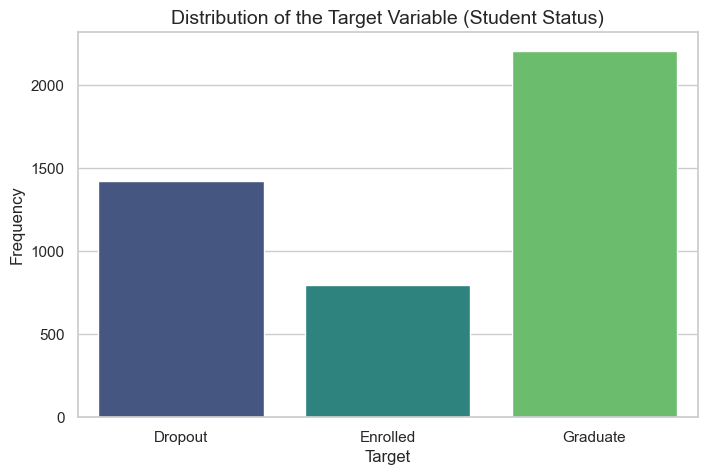

--- Resumen Estadístico de Variables Categóricas ---


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International
count,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424
unique,6,18,8,17,2,17,21,29,34,32,46,2,2,2,2,2,2,2
top,1,1,1,9500,1,1,1,1,37,9,9,1,0,0,1,0,0,0
freq,3919,1708,3026,766,3941,3717,4314,1069,1209,1577,1010,2426,4373,3921,3896,2868,3325,4314


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set visual style
sns.set_theme(style="whitegrid")

# 1.1 Distribution of the Target Variable
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Target', palette='viridis', order=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Distribution of the Target Variable (Student Status)', fontsize=14)
plt.xlabel('Target', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# 1.2 Descriptive statistics for categorical variables
# Extract categorical features (those not in Marcos's Numerical_data list and not the Target)
categorical_cols = [col for col in data.columns if col not in Numerical_data and col != 'Target']

print("--- Summary Statistics of Categorical Variables ---")
display(data[categorical_cols].astype('object').describe())

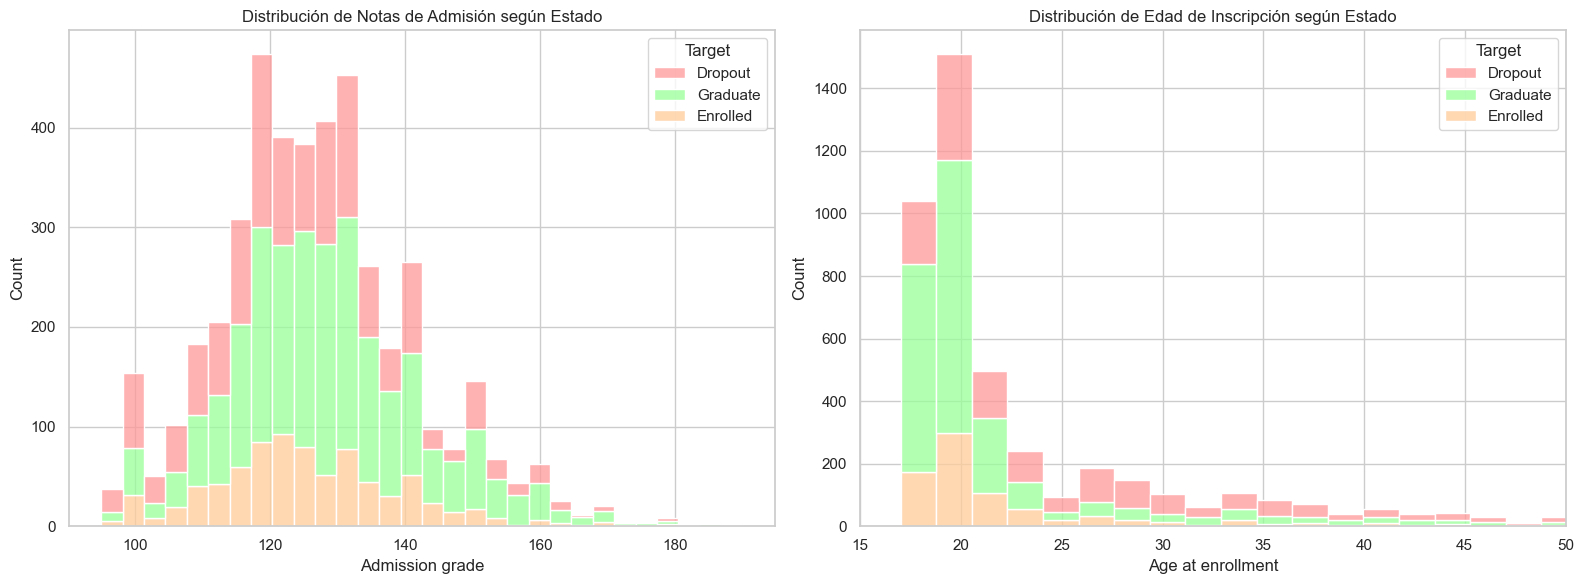

In [ ]:
# 1.3 Bivariate analysis: How do age and admission scores influence dropout rates?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of Admission Scores by Target
sns.histplot(data=data, x='Admission grade', hue='Target', multiple="stack", 
             palette={'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}, 
             ax=axes[0], bins=30)
axes[0].set_title('Distribution of Admission Scores by Student Status', fontsize=12)

# Histogram of Enrollment Age by Target
sns.histplot(data=data, x='Age at enrollment', hue='Target', multiple="stack", 
             palette={'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}, 
             ax=axes[1], bins=30)
axes[1].set_title('Distribution of Enrollment Age by Student Status', fontsize=12)
axes[1].set_xlim(15, 50) # We've narrowed down the age range for better visibility

plt.tight_layout()
plt.show()

##### Bivariate Analysis: Age and Admission Grade vs Target

**Admission Grade:**
Most students cluster in the 110-140 range. For scores under 120, the dropout rate (red) is noticeably higher than the graduation rate. Once grades pass the 130 mark, the trend reverses completely, with graduates (green) taking a clear lead. Basically, a better entrance score is a strong indicator that the student will stick with the program.

**Age at Enrollment:**
The 18-20 age group makes up the vast majority of the dataset and shows the highest success rate. However, there's a sharp shift for older students: from age 25 onwards, dropouts heavily outnumber graduates. This makes sense, as older students usually have to balance their degree with jobs or family obligations, making them much more likely to abandon their studies.

##### **2. CORRELATION MATRIX AND FEATURE SELECTION**
To ensure model interpretability and avoid multicollinearity (which can confuse the model), we will calculate Pearson's correlation matrix for numerical variables. We will use a heatmap to identify and drop redundant variables (features that give the exact same information). Finally, we'll plot a bar chart to see which features provide the most information about our Target.

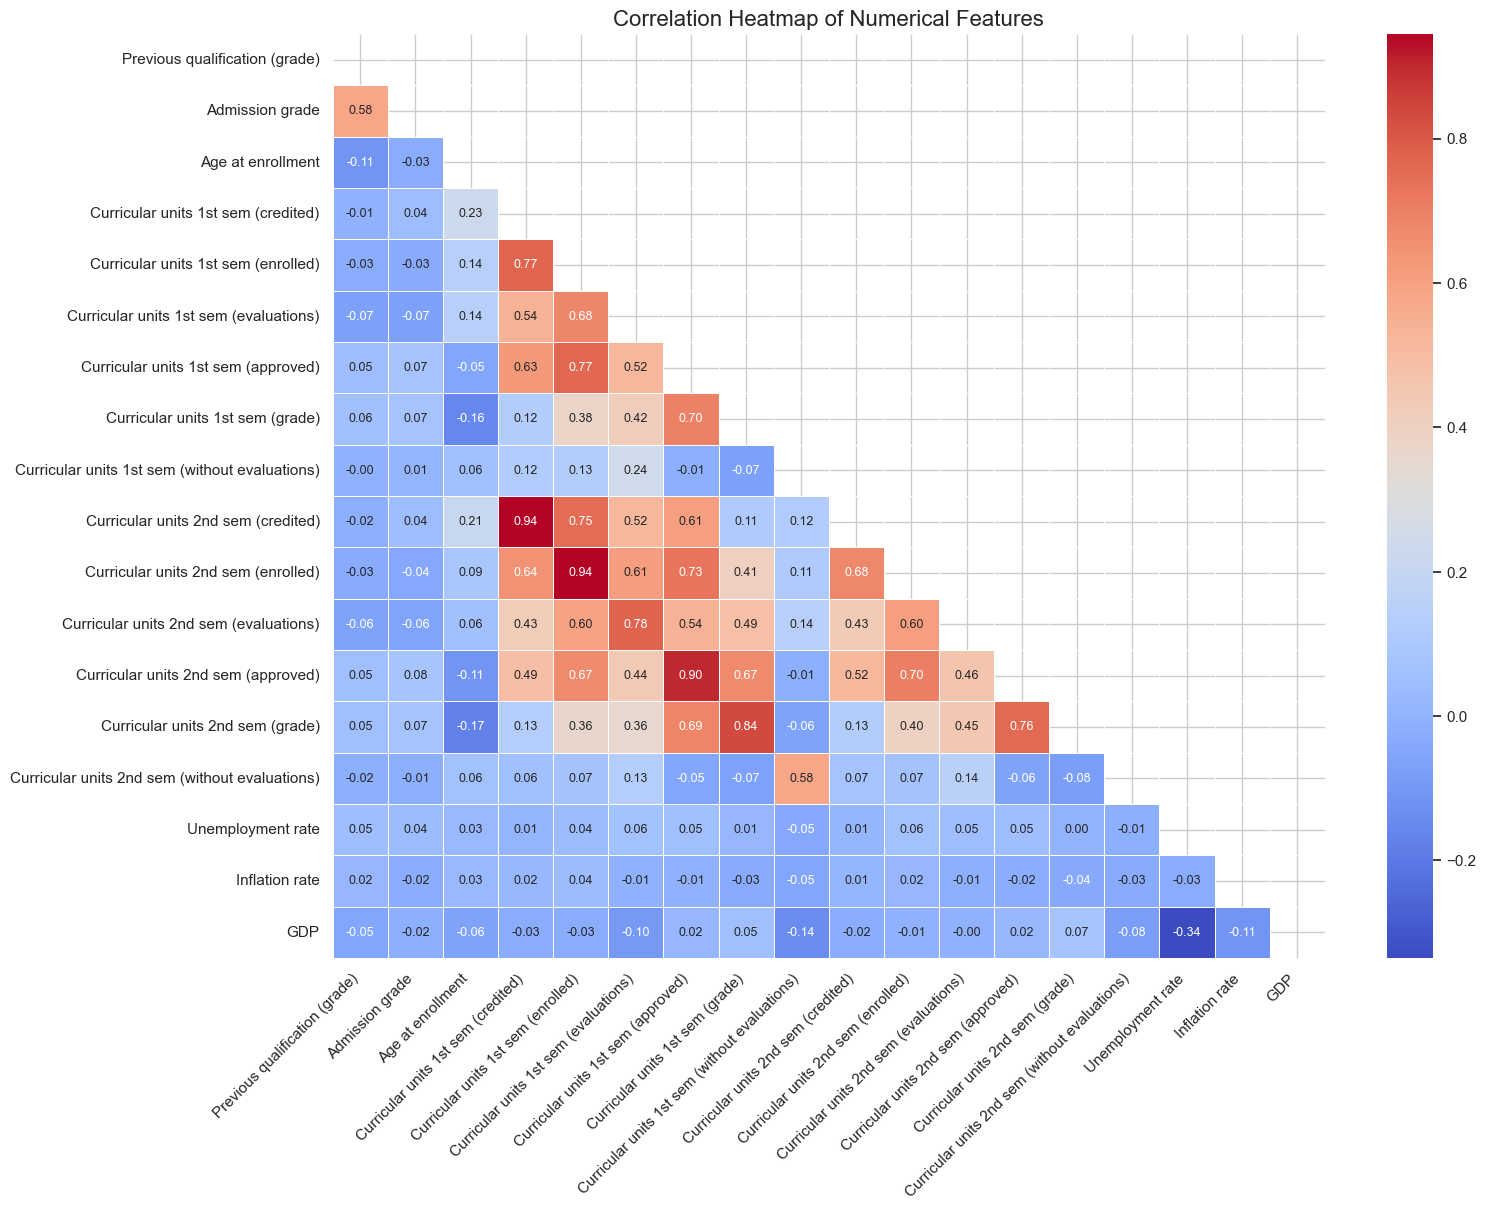

Highly correlated variables to be dropped (threshold > 0.85): 
['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']

Dataset updated. Fewer variables = Better interpretability.


C:\Users\diego\AppData\Local\Temp\ipykernel_60836\3980880155.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='mako')


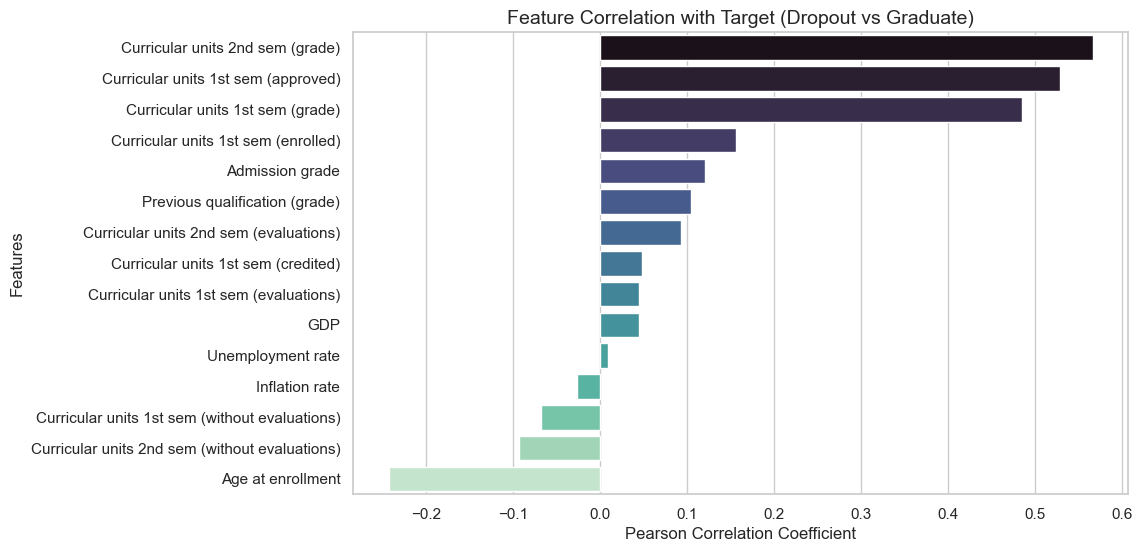

In [4]:
# 2.1 Heatmap of the correlation matrix
plt.figure(figsize=(16, 12))
corr_matrix = data[Numerical_data].corr()

# Create a mask to show only the lower triangle (cleaner visualization)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, annot_kws={"size": 9})
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

# 2.2 Identify and remove highly correlated variables (Threshold > 0.85)
# If two variables have > 0.85 correlation, they are redundant. We keep one and drop the other.
threshold = 0.85
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column].abs() > threshold)]

print(f"Highly correlated variables to be dropped (threshold > {threshold}): \n{to_drop}\n")

# Dropping the redundant variables from the dataset
data = data.drop(columns=to_drop)

# Updating the Numerical_data list
Numerical_data = [col for col in Numerical_data if col not in to_drop]
print("Dataset updated. Fewer variables = Better interpretability.")

# 2.3 Correlation with the Target
# Map Target to numerical values to calculate correlation (Dropout=0, Enrolled=1, Graduate=2)
data['Target_num'] = data['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

# Calculate correlation of remaining numerical features with the numerical Target
target_corr = data[Numerical_data + ['Target_num']].corr()['Target_num'].drop('Target_num').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='mako')
plt.title('Feature Correlation with Target (Dropout vs Graduate)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

# Remove the temporary numerical target column
data = data.drop(columns=['Target_num'])

##### **3. NOVELTY FACTOR: MACROECONOMIC VARIABLES VS DROPOUT**
We visually investigate how external macroeconomic factors (Inflation, GDP, and Unemployment rate) behave against the student's status. This helps us understand if a bad economic context influences the abandonment of studies.

C:\Users\diego\AppData\Local\Temp\ipykernel_60836\3181739379.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=data, x='Target', y=col, palette=palette_colors, order=['Dropout', 'Enrolled', 'Graduate'])
C:\Users\diego\AppData\Local\Temp\ipykernel_60836\3181739379.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=data, x='Target', y=col, palette=palette_colors, order=['Dropout', 'Enrolled', 'Graduate'])
C:\Users\diego\AppData\Local\Temp\ipykernel_60836\3181739379.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

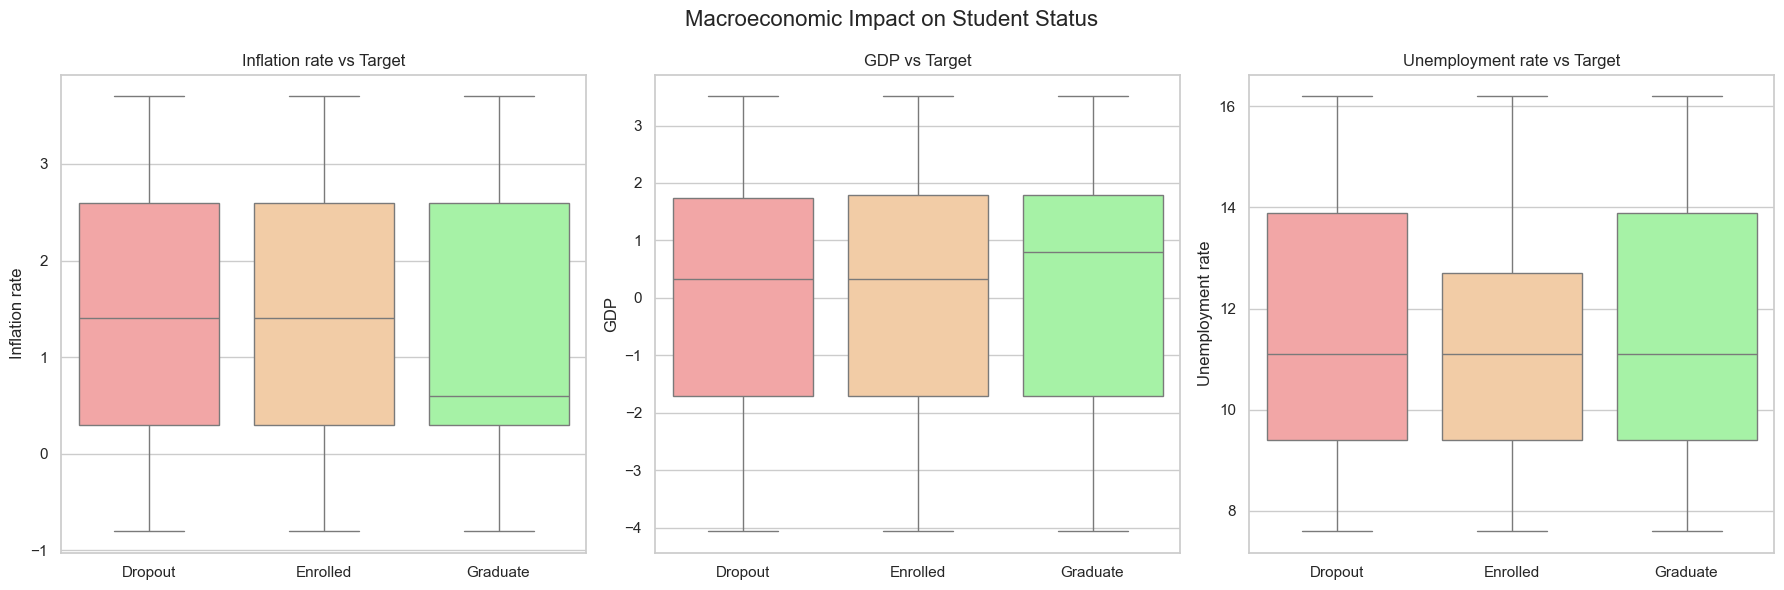

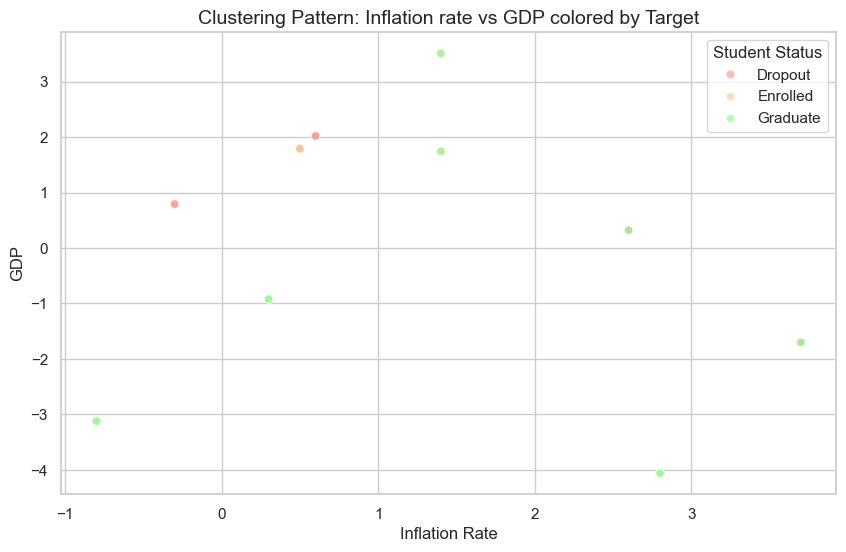

In [5]:
# 3.1 Boxplots for Macroeconomic variables vs Target
macro_vars = ['Inflation rate', 'GDP', 'Unemployment rate']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Macroeconomic Impact on Student Status', fontsize=16)

palette_colors = {'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}

for i, col in enumerate(macro_vars):
    sns.boxplot(ax=axes[i], data=data, x='Target', y=col, palette=palette_colors, order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(f'{col} vs Target', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# 3.2 Scatter plot to find clustering patterns between Inflation and GDP
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Inflation rate', y='GDP', hue='Target', 
                palette=palette_colors, alpha=0.7, hue_order=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Clustering Pattern: Inflation rate vs GDP colored by Target', fontsize=14)
plt.xlabel('Inflation Rate')
plt.ylabel('GDP')
plt.legend(title='Student Status')
plt.show()

##### CONCLUSIONS REGARDING THE PATTERNS IDENTIFIED:
1. **Curricular Redundancy:** There is a very high correlation between several 1st and 2nd-semester variables (like Curricular units enrolled vs evaluations). We can drop these overlapping features to make the model simpler to interpret without losing predictive power.

2. **Academic Impact:** As expected, the number of approved curricular units and the grades obtained are the variables with the strongest positive correlation to student graduation. 
3. **Macroeconomic Influence (Novelty Factor):** Looking at the boxplots, dropouts tend to occur more frequently in periods with higher unemployment rates and lower GDP. This suggests that external economic conditions might play an important role in a student's decision to leave university.